🔄 Generating 5,000-row Air Quality dataset...
✅ Air Quality Dataset generated inline successfully!

📊 Rendering visualization charts...


C:\Users\Admin\AppData\Local\Temp\ipykernel_11076\3833422843.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Location", y="AQI", data=df, palette="pastel")


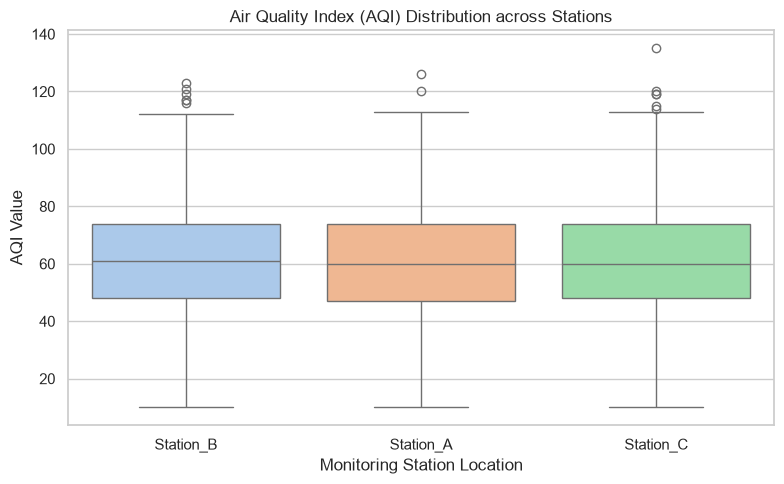

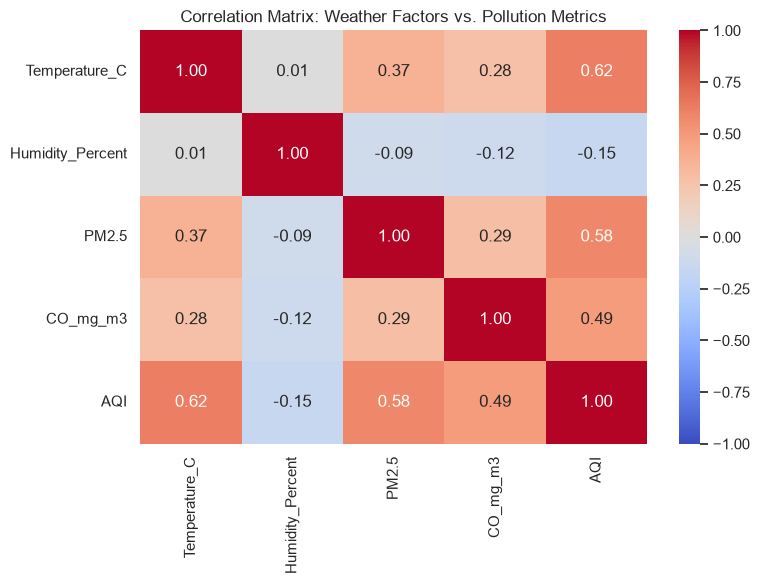

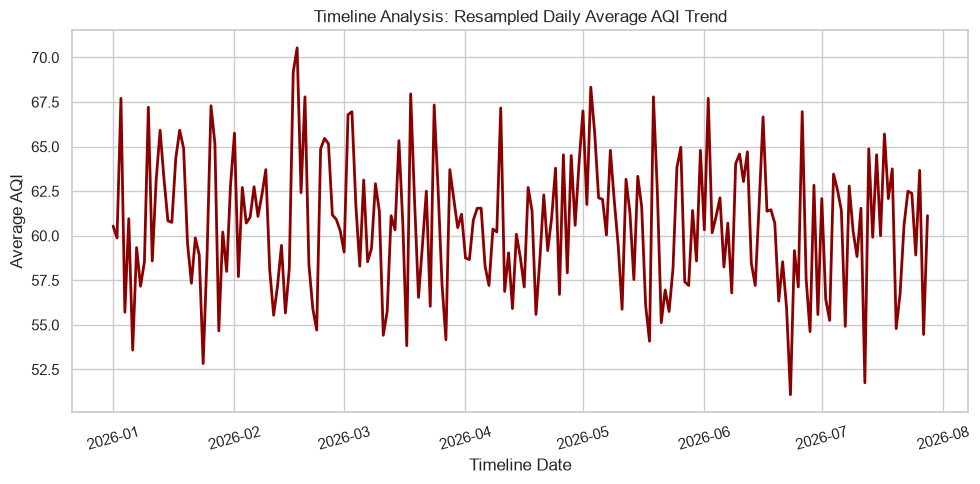

C:\Users\Admin\AppData\Local\Temp\ipykernel_11076\3833422843.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


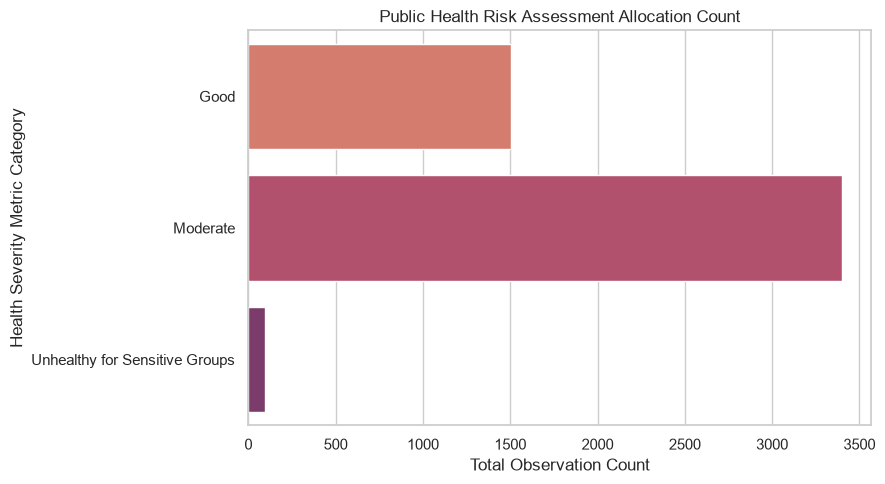

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =====================================================================
# STEP 1: AUTOMATIC REALISTIC DATASET GENERATION (5,000 Records)
# =====================================================================
print("🔄 Generating 5,000-row Air Quality dataset...")
np.random.seed(101)
num_samples = 5000

# Generating Dates over time
date_range = pd.date_range(start="2026-01-01", periods=num_samples, freq="h")

# Locations
locations = np.random.choice(
    ["Station_A", "Station_B", "Station_C"], size=num_samples, p=[0.4, 0.35, 0.25]
)

# Weather Features
temperature = np.random.normal(loc=22, scale=8, size=num_samples)
humidity = np.clip(np.random.normal(loc=60, scale=15, size=num_samples), 10, 100)


# Pollution Indicators (Correlated with Temperature/Stagnant conditions)
def generate_aqi(temp, hum):
    # Higher temperature and lower humidity often increase ozone/particle aggregation indicators
    base_aqi = 40 + (temp * 1.5) - (hum * 0.2) + np.random.normal(0, 15)
    return np.clip(base_aqi, 10, 500)  # Standard AQI bounds


aqi = [generate_aqi(t, h) for t, h in zip(temperature, humidity)]

# Individual Pollutants (PM2.5 and CO)
pm25 = [a * 0.18 + np.random.normal(0, 5) for a in aqi]
co_levels = [a * 0.006 + np.random.normal(0, 0.2) for a in aqi]

# Introduce realistic Missing Values (NaN) into the data matrix
pm25_array = np.array(pm25)
pm25_array[
    np.random.choice(num_samples, size=int(num_samples * 0.05), replace=False)
] = np.nan

# Constructing DataFrame
df = pd.DataFrame(
    {
        "Timestamp": date_range,
        "Location": locations,
        "Temperature_C": np.round(temperature, 1),
        "Humidity_Percent": np.round(humidity, 1),
        "PM2.5": np.round(np.clip(pm25_array, 0, None), 2),
        "CO_mg_m3": np.round(np.clip(co_levels, 0.1, None), 2),
        "AQI": np.round(aqi, 0).astype(int),
    }
)

# Derive Public Health Category based on EPA guidelines
conditions = [
    (df["AQI"] <= 50),
    (df["AQI"] <= 100),
    (df["AQI"] <= 150),
    (df["AQI"] > 150),
]
categories = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy"]
df["Health_Impact"] = np.select(conditions, categories, default="Hazardous")

print("✅ Air Quality Dataset generated inline successfully!\n")

# =====================================================================
# STEP 2: MULTI-VARIABLE VISUALIZATION ENGINE
# =====================================================================
print("📊 Rendering visualization charts...")
sns.set_theme(style="whitegrid")

# --- CHART 1: Distribution of Overall AQI by Location ---
plt.figure(figsize=(8, 5))
sns.boxplot(x="Location", y="AQI", data=df, palette="pastel")
plt.title("Air Quality Index (AQI) Distribution across Stations")
plt.xlabel("Monitoring Station Location")
plt.ylabel("AQI Value")
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 2: Correlation Analysis (Weather vs Pollutants) ---
plt.figure(figsize=(8, 6))
numeric_cols = ["Temperature_C", "Humidity_Percent", "PM2.5", "CO_mg_m3", "AQI"]
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: Weather Factors vs. Pollution Metrics")
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 3: Air Quality Trends Over Time (Daily Resampled Average) ---
plt.figure(figsize=(10, 5))
df_time = df.set_index("Timestamp")
df_daily = df_time["AQI"].resample("D").mean().reset_index()

sns.lineplot(x="Timestamp", y="AQI", data=df_daily, color="darkred", linewidth=2)
plt.title("Timeline Analysis: Resampled Daily Average AQI Trend")
plt.xlabel("Timeline Date")
plt.ylabel("Average AQI")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()  # 💡 CLOSE THIS WINDOW FOR THE NEXT CHART TO APPEAR

# --- CHART 4: Public Health Impact Assessment Proportion ---
plt.figure(figsize=(9, 5))
order = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Hazardous",
]
sns.countplot(
    y="Health_Impact",
    data=df,
    order=[cat for cat in order if cat in df["Health_Impact"].unique()],
    palette="flare",
)
plt.title("Public Health Risk Assessment Allocation Count")
plt.xlabel("Total Observation Count")
plt.ylabel("Health Severity Metric Category")
plt.tight_layout()
plt.show()